# Packages

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt

# Loading the data

This notebook contains the code to generate the plots for the lung data, meaning figure 1 a,b, and c, figure 3 a, and b, and supplementary figure 1 a, and b. For this purpose we need to load the lung dataset, which is dowloadable at: **provide link** 

In [3]:
lung_cd3 = sc.read_h5ad('/media/david/DiskExtension/Collaborations/GFI1_Canada/datasets_publication_v1/lung_cd3.h5ad')

lung_cd3

AnnData object with n_obs × n_vars = 3232 × 19177
    obs: 'genotype', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_gm', 'log1p_total_counts_gm', 'pct_counts_gm', 'n_counts', 'n_genes', 'leiden', 'cell_type'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'gm', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'genotype_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'log1p_norm', 'raw_data', 'scaled'
    obsp: 'connectivities', 'distances'

# Figure 1

## a)

In [11]:
colors = [
    '#66c5cc','#f6cf71','#f89c74',
    '#dcb0f2','#87c55f','#9eb9f3',
    '#fe88b1','#c9db74','#8be0a4',
    '#b497e7','#d3b484','#b3b3b3',
]
cluster_colors = {
    f'{i}': colors[i] for i in range(12)
}

Text(0.5, 1.0, 'Clusters')

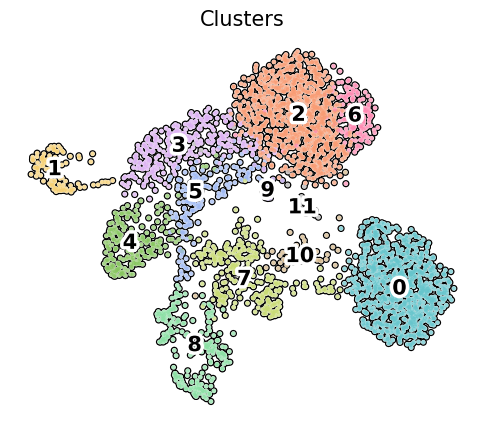

In [24]:
fig, axes = plt.subplots(1,1, figsize=(6,5))

sc.pl.umap(
    lung_cd3,
    color='leiden',
    legend_loc='on data',
    palette=cluster_colors,
    add_outline=True,
    legend_fontoutline=5,
    legend_fontsize=15,
    frameon=False,
    ax=axes, show=False
)

axes.set_title(
    'Clusters',
    fontsize=15
)

# plt.savefig(
#     '/media/david/DiskExtension/Collaborations/GFI1_Canada/figures_paper_v1/lung_data/lung_wt_cd3_umap_cluster.pdf',
#     bbox_inches='tight'
# )

## b)

In [ ]:
colors = [
    '#66c2a5','#fc8d62','#8da0cb','#e78ac3',
]

cell_type_colors = {cell_type: colors[i] for i,cell_type in enumerate(lung_cd3.obs['cell_type'].unique())}

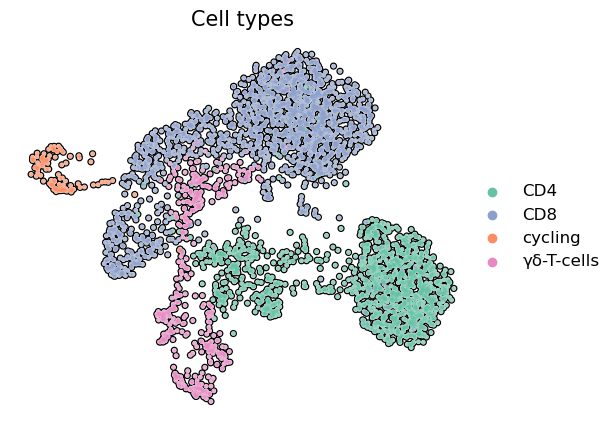

In [ ]:
fig, axes = plt.subplots(1,1, figsize=(6,5))

sc.pl.umap(
    lung_cd3,
    color='cell_type',
    # legend_loc='on data',
    palette=cell_type_colors,
    add_outline=True,
    legend_fontoutline=5,
    legend_fontsize=15,
    frameon=False,
    ax=axes, show=False,
)

axes.set_title(
    'Cell types',
    fontsize=15
)

# Change the gd-T-cells annotation to have greek letters
handles, labels = axes.get_legend_handles_labels()

labels[labels.index(r'gd-T-cells')] = r'γδ-T-cells'

axes.legend(
    handles,
    labels,
    loc='center right',
    bbox_to_anchor=(1.3, 0.5),
    title=None,
    fontsize=12,
    frameon=False
)

# plt.savefig(
#     '/media/david/DiskExtension/Collaborations/GFI1_Canada/figures_paper_v1/lung_data/lung_wt_cd3_umap_celltypes.pdf',
#     bbox_inches='tight'
# )

## c)

In order to plot the distribution of cell types across genotype, we first have to extract the cells the and the respective metadata from the anndata object, count the cells per group and then normalize the value by genotype by dividing by the total number of cells in the specific genotype.

In [ ]:
# Extract cells and their metadata
df_barplot_all_celltypes = sc.get.obs_df(
    lung_cd3,
    keys=['genotype', 'cell_type'],
)

df_barplot_all_celltypes = (
    df_barplot_all_celltypes
    # Count cells by genotype and cell type
    .groupby(['genotype', 'cell_type'], observed=True)
    .size()
    .reset_index(name='count')
    # Normalize by genotype and convert to percentage
    .assign(
        count_normalized=lambda x: x['count'] / x.groupby('genotype', observed=True)['count'].transform('sum') * 100
    )
)

For simplicity we draw the barplot using the in-built pandas funtion on a wide format of the dataframe, where the columns are the cell types and the rows are the genotypes.

<positron-console-cell-41>:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


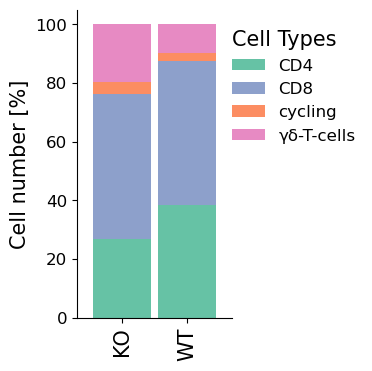

In [41]:
p1 = (
    df_barplot_all_celltypes
    # Pivoting data frame from long to wide
    .pivot(
        index='genotype',
        columns='cell_type',
        values='count_normalized'
    )
    # Plot it using pandas in-built function
    .plot(
        kind='bar', 
        stacked=True,
        width=0.9,
        color=cell_type_colors,
        figsize=(2,4)
    )
)

# Change the gd-T-cell annotation to have greek letter
handles, labels = p1.get_legend_handles_labels()

labels[labels.index(r'gd-T-cells')] = r'γδ-T-cells'

p1.legend(
    handles=handles,
    labels=labels,
    loc='center left',
    bbox_to_anchor=(0.9, 0.75),
    title='Cell Types',
    fontsize=12,
    title_fontsize=15,
    frameon=False,
    alignment='left'
)

p1.set_ylabel('Cell number [%]', fontsize=15)
p1.set_yticklabels([0,20,40,60,80,100], fontsize=12)
p1.set_xlabel('')
p1.set_xticklabels(['KO', 'WT'], fontsize=15)

p1.spines['right'].set_visible(False)
p1.spines['top'].set_visible(False)

# plt.savefig(
#     '/media/david/DiskExtension/Collaborations/GFI1_Canada/figures_paper_v1/lung_data/lung_wt_cd3_barplot_celltypes.pdf',
#     bbox_inches='tight'
# )

# Figure 3

## a)

In this plot we only want to see the expression of the selected genes in clusters 5 and 8. 

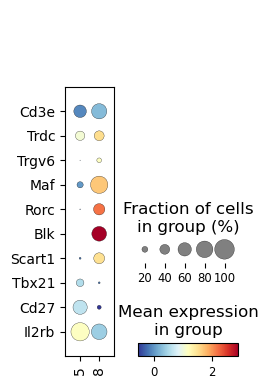

In [ ]:
# List of genes
genes = ['Cd3e', 'Trdc', 'Trgv6', 'Maf', 'Rorc', 'Blk', 'Scart1', 'Tbx21', 'Cd27', 'Il2rb']

fig = sc.pl.dotplot(
    # Subset to only use cells in clusters 5 and 8
    lung_cd3[lung_cd3.obs['leiden'].isin(['5', '8'])],
    var_names=genes,
    groupby='leiden',
    cmap='RdYlBu_r',
    # Return fig for customization
    return_fig=True,
    swap_axes=True
)

axes = fig.get_axes()

axes['mainplot_ax'].tick_params('x', labelsize=10)
axes['mainplot_ax'].tick_params('y', labelsize=10)

axes['size_legend_ax'].title.set_fontsize(12)
axes['color_legend_ax'].title.set_fontsize(12)

# plt.savefig(
#     '/media/david/DiskExtension/Collaborations/GFI1_Canada/figures_paper_v1/lung_data/lung_wt_cd3_dotplot_c5_c8.pdf',
#     bbox_inches='tight'
# )

## b)

In this plot we only want to show the distribution of clusters 5 and 8 across wildtype and knock-out, so we count the cells only if they are in cluster 5 or 8. Then we proceed as in figure 1c.

In [27]:
# Extract cells and their metadata
df_barplot_c5_c8 = sc.get.obs_df(
    lung_cd3[lung_cd3.obs['leiden'].isin(['5', '8'])],
    keys=['genotype', 'leiden'],
)

df_barplot_c5_c8 = (
    df_barplot_c5_c8
    # Count cells by genotype and cell type
    .groupby(['genotype', 'leiden'], observed=True)
    .size()
    .reset_index(name='count')
    # Normalize by genotype and convert to percentage
    .assign(
        count_normalized=lambda x: x['count'] / x.groupby('genotype', observed=True)['count'].transform('sum') * 100
    )
)

<positron-console-cell-37>:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


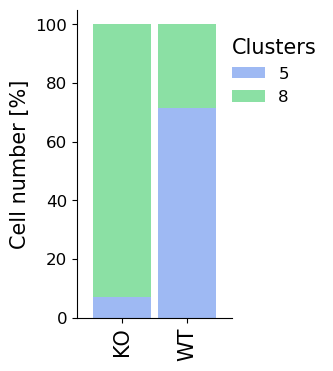

In [ ]:
p1 = (
    df_barplot_c5_c8
    # Pivoting data frame from long to wide
    .pivot(
        index='genotype',
        columns='leiden',
        values='count_normalized'
    )
    # Plot it using pandas in-built function
    .plot(
        kind='bar', 
        stacked=True,
        width=0.9,
        color=cluster_colors,
        figsize=(2,4)
    )
)

# Customize legend
p1.legend(
    loc='center left',
    bbox_to_anchor=(0.9, 0.8),
    title='Clusters',
    fontsize=12,
    title_fontsize=15,
    frameon=False,
    alignment='left'
)

p1.set_ylabel('Cell number [%]', fontsize=15)
p1.set_yticklabels([0,20,40,60,80,100], fontsize=12)
p1.set_xlabel('')
p1.set_xticklabels(['KO', 'WT'], fontsize=15)

p1.spines['right'].set_visible(False)
p1.spines['top'].set_visible(False)

# plt.savefig(
#     '/media/david/DiskExtension/Collaborations/GFI1_Canada/figures_paper_v1/lung_data/lung_wt_cd3_barplot_c5_c8.pdf',
#     bbox_inches='tight'
# )

# Supplementary figure 1

## b)

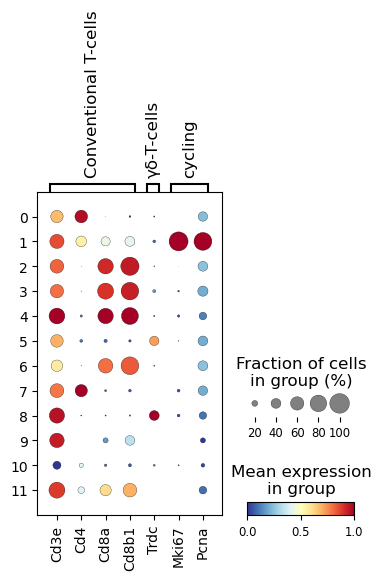

In [44]:
# Dictionary of genes
gene_groups = {
    'Conventional T-cells': ['Cd3e', 'Cd4', 'Cd8a', 'Cd8b1'],
    'γδ-T-cells': ['Trdc'],
    'cycling': ['Mki67', 'Pcna']
}

fig = sc.pl.dotplot(
    lung_cd3,
    var_names=gene_groups,
    groupby='leiden',
    cmap='RdYlBu_r',
    standard_scale='var',
    # Return fig for customization
    return_fig=True
)

axes = fig.get_axes()

axes['mainplot_ax'].tick_params('x', labelsize=10)
axes['mainplot_ax'].tick_params('y', labelsize=10)

for text in axes['gene_group_ax'].texts:
    text.set_fontsize(12)

axes['size_legend_ax'].title.set_fontsize(12)
axes['color_legend_ax'].title.set_fontsize(12)

# plt.savefig(
#     '/media/david/DiskExtension/Collaborations/GFI1_Canada/figures_paper_v1/lung_data/lung_wt_cd3_dotplot_labels.pdf',
#     bbox_inches='tight'
# )